Loading required package: NbClust

Warning message in cor(numData, use = "pairwise.complete.obs"):
"the standard deviation is zero"



<U+0001F539> Processing index: silhouette 
<U+2705> Best number of clusters (silhouette) = 100

<U+0001F539> Processing index: dunn 
<U+2705> Best number of clusters (dunn) = 5


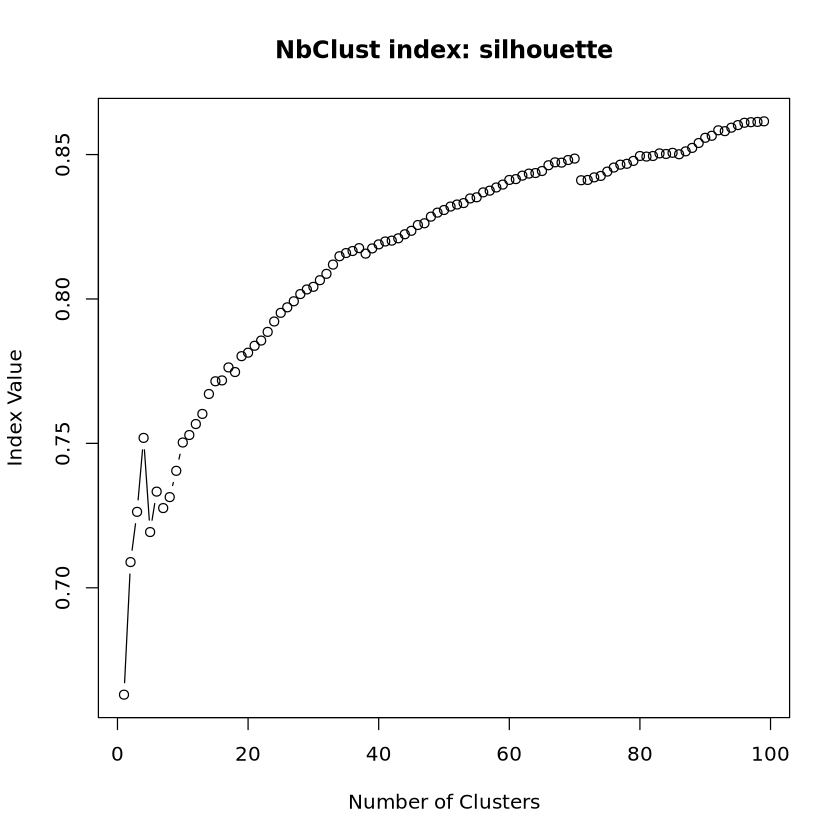


<U+0001F539> Processing index: gap 
<U+2705> Best number of clusters (gap) = 2


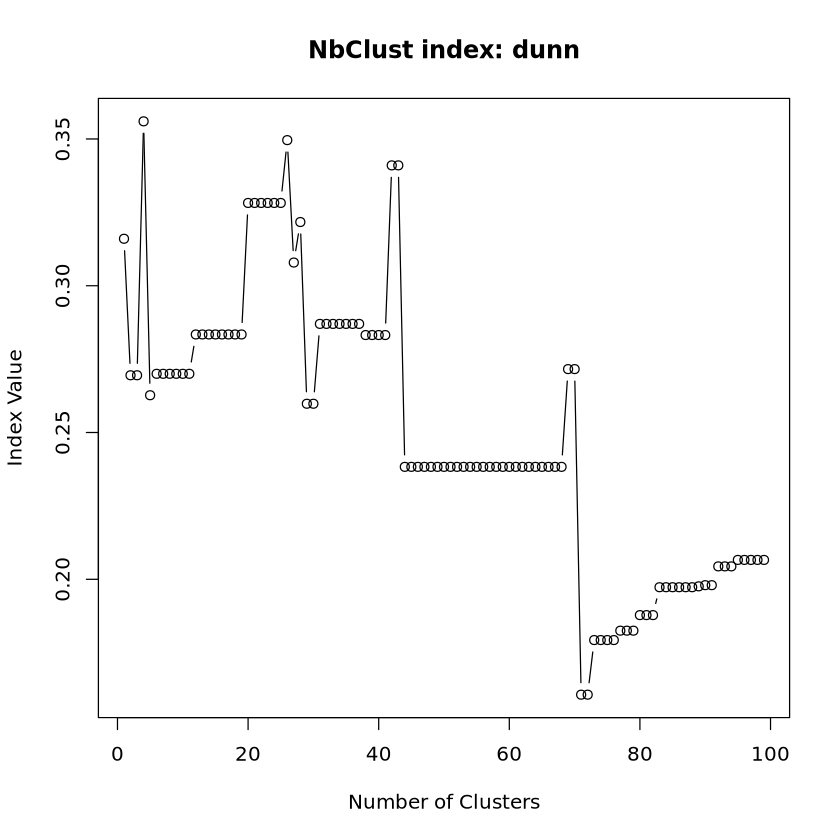


<U+0001F539> Processing index: ch 
<U+2705> Best number of clusters (ch) = 100


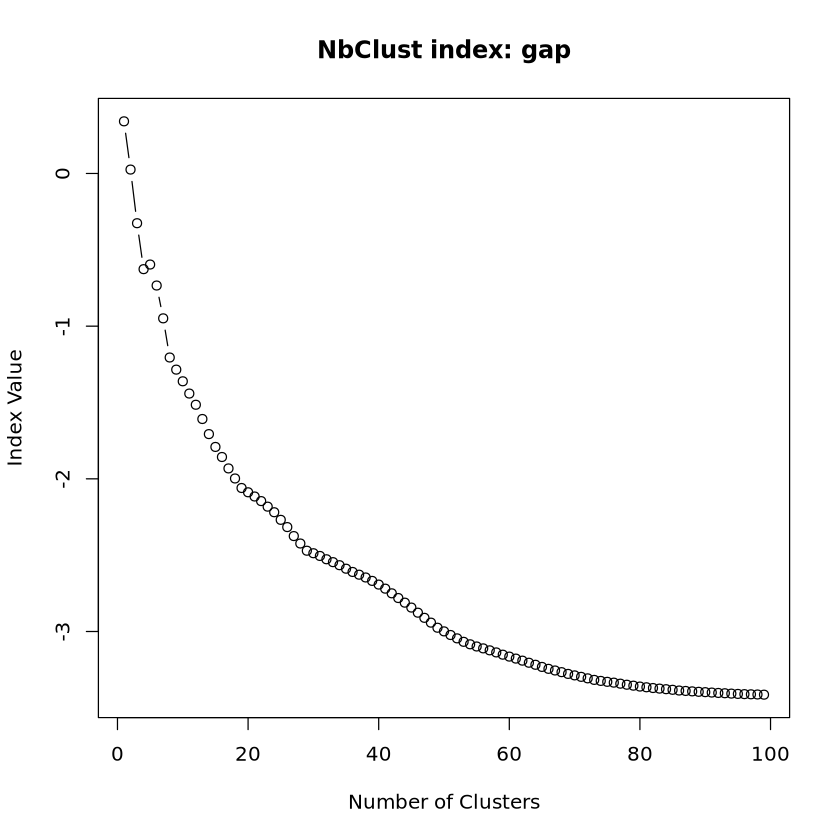


<U+0001F539> Processing index: db 
<U+2705> Best number of clusters (db) = 5


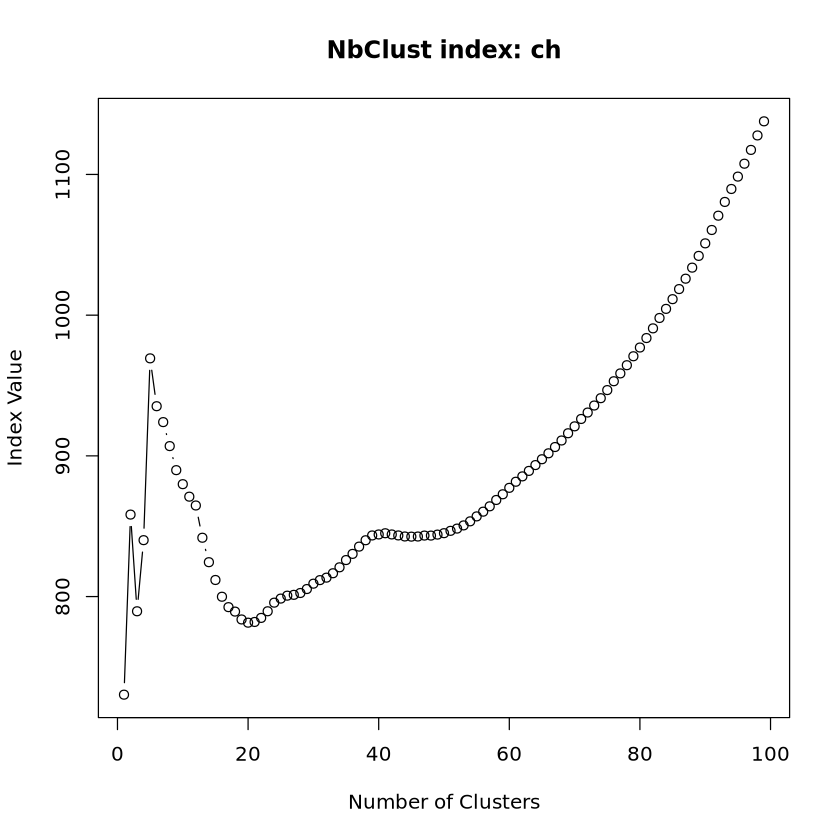


<U+0001F539> Processing index: ptbiserial 
<U+2705> Best number of clusters (ptbiserial) = 5


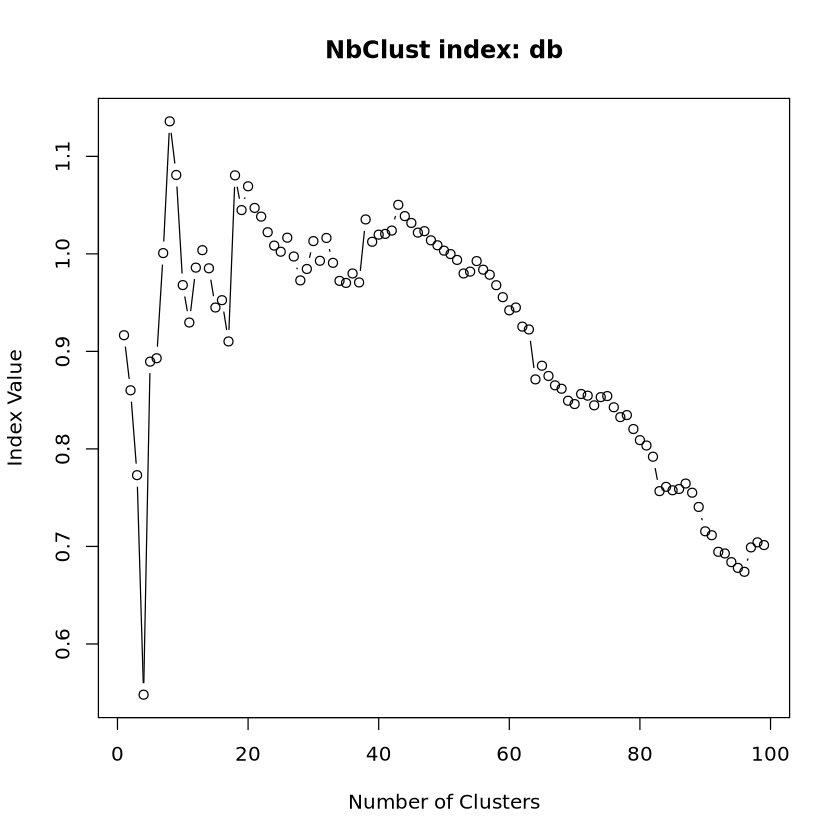

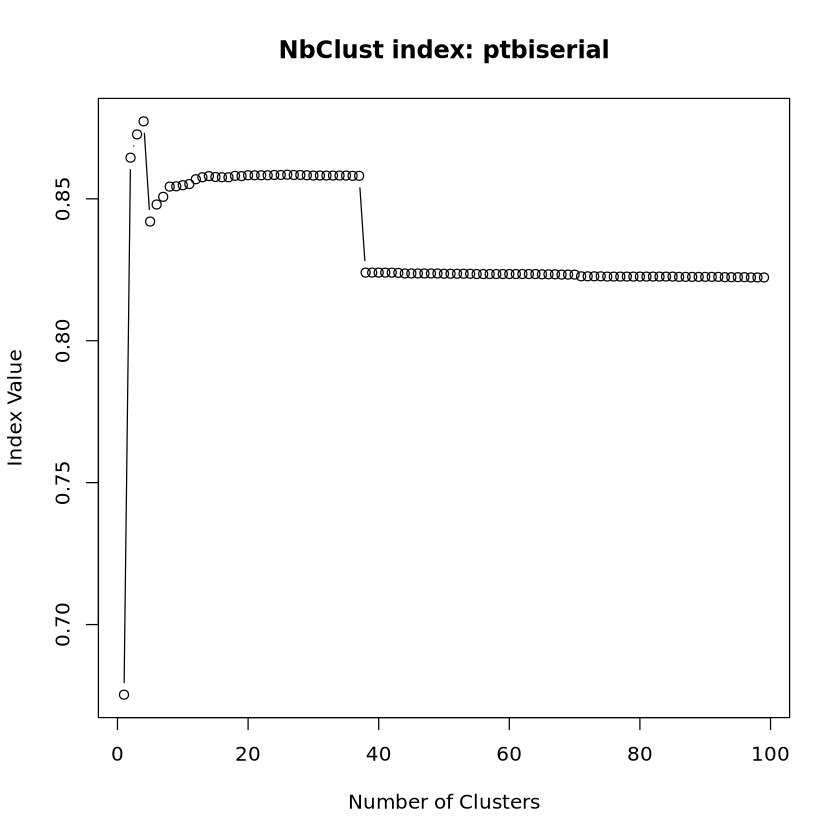

In [1]:
# --- パッケージの読み込み・インストール ---
if (!require(NbClust)) {
  install.packages("NbClust")
  library(NbClust)
}

# --- データの読み込み ---
ifname <- "DataMerge20211220FP_20250715.csv"
readData <- read.delim(ifname, header = TRUE, sep = ",", row.names = 1, as.is = TRUE, strip.white = FALSE)

# --- 数値データの抽出と前処理（標準偏差ゼロの列除去） ---
numData <- readData[, sapply(readData, is.numeric)]
# numData <- numData[, apply(numData, 2, sd, na.rm = TRUE) != 0]

# --- 相関距離行列の作成 ---
corData <- cor(numData, use = "pairwise.complete.obs")
corData[is.na(corData)] <- 0
ddata <- dist(1 - abs(corData))  # absをとることで相関の強さ重視

# --- MDS（主座標分析） ---
Nvars <- ncol(numData)
kmax <- min(Nvars - 1, 100)  # 最大クラスタ数を30に制限
if (kmax < 2) stop("⚠️ 変数数が少なすぎてクラスタリングできません")

mdsdata <- cmdscale(ddata, k = kmax, eig = TRUE)

# --- 実用的な評価指標のみに絞る（重い指標は省略） ---
index_list <- c("silhouette", "dunn", "gap", "ch", "db", "ptbiserial")

# --- クラスタ出力ディレクトリの作成（任意） ---
# dir.create("cluster_outputs", showWarnings = FALSE)

# --- 評価指標ごとにクラスタ数探索 ---
for (cindex in index_list) {
  cat("\n🔹 Processing index:", cindex, "\n")

  tryCatch({
    clustEst <- NbClust(
      data = mdsdata$points,
      diss = NULL,
      distance = "euclidean",
      min.nc = 2,
      max.nc = kmax,
      method = "ward.D2",
      index = cindex
    )

    # --- 結果の要約表示 ---
    best_nc <- clustEst$Best.nc[1]
    cat(paste0("✅ Best number of clusters (", cindex, ") = ", best_nc, "\n"))

    # --- 結果を保存 ---
    grpname <- as.factor(clustEst$Best.partition)
    fn <- paste0("NbClust_", cindex, "_Grp_delSTD0_0717_FP.csv")
    write.csv(grpname, file = fn)

    # --- スコアプロット ---
    plot(clustEst$All.index, type = "b",
         main = paste("NbClust index:", cindex),
         xlab = "Number of Clusters", ylab = "Index Value")

  }, error = function(e) {
    warning(paste("⚠️ Index", cindex, "failed:", e$message))
  })
}
